
# Expectation Decider – Probability Analysis Project

This notebook contains:
- Dataset generation
- Probability concepts
- Empirical and theoretical probability
- Random variable distribution
- Contingency table analysis
- Conditional probability
- Bayes Theorem
- Charts and diagrams


In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)


## 1. Generate Dataset

In [3]:

n = 200

study_hours = np.random.randint(2, 21, n)
attendance = np.random.randint(50, 101, n)
group_discussion = np.random.choice(['Yes', 'No'], n, p=[0.6, 0.4])
previous_test_score = np.random.randint(35, 101, n)

score = (
    0.25 * study_hours +
    0.25 * (attendance / 10) +
    0.4 * (previous_test_score / 10) +
    np.where(group_discussion == 'Yes', 2, 0)
)

final_exam_pass = np.where(score > 9, 'Pass', 'Fail')

df = pd.DataFrame({
    'study_hours': study_hours,
    'attendance': attendance,
    'group_discussion': group_discussion,
    'previous_test_score': previous_test_score,
    'final_exam_pass': final_exam_pass
})

df.head()


,study_hours,attendance,group_discussion,previous_test_score,final_exam_pass
0,8,60,Yes,90,Pass
1,16,77,No,64,Fail
2,12,74,No,39,Fail
3,9,99,No,67,Fail
4,8,72,Yes,99,Pass



## 2. Understanding Probability:

### What is Probability?
Probability is a measure of the likelihood that a particular event will occur.

- 0 means the event cannot happen.
- 1 means the event is certain to happen.

### Key Terminology :-
- Experiment
- Outcome
- Sample space
- Event
- Favorable outcomes

## Types Of Probability :-
- Theoretical
- Experimental (Empiricial)
- Subjective


## 3. Empirical Probability

In [4]:

pass_count = (df['final_exam_pass'] == 'Pass').sum()
pass_probability = pass_count / len(df)

print("Number of students who passed:", pass_count)
print("Empirical Probability of Passing:", round(pass_probability, 2))


Number of students who passed: 73
Empirical Probability of Passing: 0.36


## 4. Random Variable & Probability Distribution

In [5]:

p = pass_probability

x_values = [0, 1, 2, 3]

probabilities = [
    (1-p)**3,
    3*p*(1-p)**2,
    3*(p**2)*(1-p),
    p**3
]

distribution = pd.DataFrame({
    'X': x_values,
    'P(X)': probabilities
})

distribution


,X,P(X)
0,0,0.256048
1,1,0.441531
2,2,0.253794
3,3,0.048627


In [6]:

mean = 3 * p
variance = 3 * p * (1-p)

print("Mean:", round(mean, 2))
print("Variance:", round(variance, 2))


Mean: 1.1
Variance: 0.7


## 5. Venn Diagram Concepts

In [7]:

study_condition = df['study_hours'] > 10
attendance_condition = df['attendance'] > 80

both = (study_condition & attendance_condition).sum()

print("Students studying >10 hours:", study_condition.sum())
print("Students with attendance >80%:", attendance_condition.sum())
print("Students satisfying both conditions:", both)


Students studying >10 hours: 90
Students with attendance >80%: 89
Students satisfying both conditions: 38


## 6. Contingency Table

In [8]:

contingency_table = pd.crosstab(
    df['group_discussion'],
    df['final_exam_pass']
)

contingency_table


final_exam_pass,Fail,Pass
group_discussion,,
No,80,8
Yes,47,65


In [9]:

joint_probability = len(
    df[(df['group_discussion'] == 'Yes') &
       (df['final_exam_pass'] == 'Pass')]
) / len(df)

marginal_probability = pass_probability

conditional_probability = (
    len(df[(df['group_discussion'] == 'Yes') &
           (df['final_exam_pass'] == 'Pass')])
    /
    len(df[df['group_discussion'] == 'Yes'])
)

print("Joint Probability:", round(joint_probability, 2))
print("Marginal Probability:", round(marginal_probability, 2))
print("Conditional Probability:", round(conditional_probability, 2))


Joint Probability: 0.33
Marginal Probability: 0.36
Conditional Probability: 0.58


## 7. Relationship Between Events

In [10]:

p_yes = len(df[df['group_discussion'] == 'Yes']) / len(df)

if abs(joint_probability - (p_yes * pass_probability)) > 0.01:
    print("Events are dependent.")
else:
    print("Events are independent.")


Events are dependent.


## 8. Bayes Theorem

In [11]:

P_high_given_pass = 0.70
P_high = 0.60

P_pass = pass_probability

bayes_result = (P_high_given_pass * P_pass) / P_high

print("P(Pass | High Attendance) =", round(bayes_result, 2))


P(Pass | High Attendance) = 0.43


## 9. Visualization

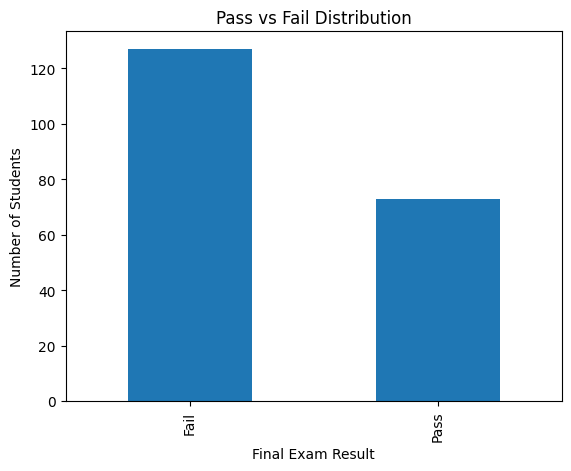

In [12]:

df['final_exam_pass'].value_counts().plot(kind='bar')

plt.xlabel('Final Exam Result')
plt.ylabel('Number of Students')
plt.title('Pass vs Fail Distribution')

plt.show()



## 10. Final Summary

The analysis shows:
- Higher study hours improve chances of passing.
- Higher attendance improves performance.
- Students participating in group discussions perform better.
- Previous test scores strongly affect final exam results.

Probability techniques such as conditional probability, contingency tables, and Bayes Theorem help understand student performance patterns.
